In [1]:
from jax import random, numpy as jnp
from lqg import xcorr
import matplotlib.pyplot as plt

from cppp.models.multisensory import MultisensoryDelayModel, MultisensoryDelayModelPointMassDynamics, SubjectiveMultisensoryDelayModelPointMassDynamics


In [5]:
params = {"action_cost": 0.05, "m": 1., "tau": 0.066, "dt": 0.075, "delays": [1], "T": 1000, "action_variability": 0.1, "process_noise": 1.0, "sigmas": [1.0]}

force_model = MultisensoryDelayModelPointMassDynamics(
    **params
)

subj_model = SubjectiveMultisensoryDelayModelPointMassDynamics(
        subj_process_noise=1.,
        subj_vel_process_noise=1.,
        **params
)


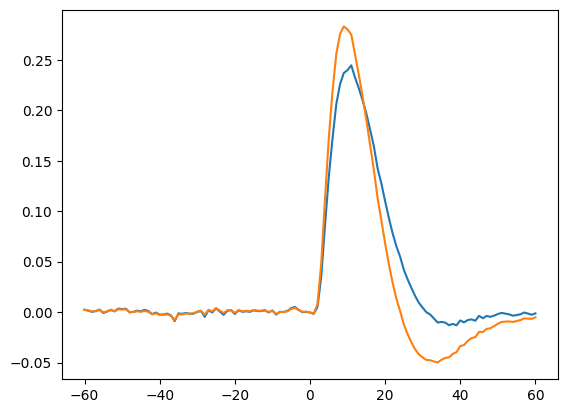

In [6]:
for model in [force_model, subj_model]:
    key = random.PRNGKey(0)
    x = model.simulate(key, n=100)
    print(model)
    vels = jnp.diff(x, axis=-2)
    lags, correls = xcorr(vels[..., 1], vels[..., 0], maxlags=60)

    plt.plot(lags, correls.mean(axis=0))